FIX THIS UP!!

This notebook combines all of the data following the data-labeling session into a single large CSV file

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import ast # turns str(list(int)) to list(int)
import matplotlib.pyplot as plt

In [ ]:
session_dir = Path('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11')

# Create the samples CSV

Read the CSV files from each group. Drop all of the trailing empty columns b/c people didn't fill those out

In [3]:
all_pdf_dfs = {}
for group_idx in range(1, 16):
    df = pd.read_csv(data_dir / f'group{group_idx}' / f'labels_{group_idx}.csv', index_col = 0)

    non_empty_mask = (df != '') & df.notna()
    cols_with_data = non_empty_mask.any(axis=0)

    if cols_with_data.any():
        last_col = cols_with_data[cols_with_data].index[-1]  # name of last non-empty column
        df = df.loc[:, :last_col]  # keep columns up to last non-empty
    else:
        continue  # skip entirely empty DataFrames

    df.columns = df.columns.astype(int)
    all_pdf_dfs[group_idx] = df


In [ ]:
all_samples = []  

for idx, row in key_df.iterrows():

    pdf_num = row['pdf_num']
    stack_num = row['stack_num']
    labeled_scans = np.array(ast.literal_eval(row['labeled_scans']))
    num_scans = row['num_scans']

    if pdf_num not in all_pdf_dfs: # pdf was never labeled
        continue 

    pdf_df = all_pdf_dfs[pdf_num]

    if stack_num not in pdf_df: # stack was never labeled and dropped in previous box
        continue
    
    # ----------------
    # Get which scans are bad/questionable/good

    flagged_scans = pdf_df[stack_num].dropna().astype(str)

    if flagged_scans.str.contains('SKIP').any(): # skip this stack!
        continue 

    is_questionable = flagged_scans.str.contains('?', regex = False)

    quest_scans = flagged_scans[is_questionable].str[:-1].astype(float).astype(int).to_numpy()
    bad_scans = flagged_scans[~is_questionable].astype(float).astype(int).to_numpy()

    if -1 in bad_scans:
        bad_scans = labeled_scans
        
    assert np.all(np.isin(quest_scans, labeled_scans))
    assert np.all(np.isin(bad_scans, labeled_scans)), f"{pdf_num}, {stack_num}, {bad_scans}n{labeled_scans}"


    good_scans = set(labeled_scans) - set(bad_scans) - set(quest_scans)

    # ----------------
    # Save all of these datapoints to final DF
    # 0 = GOOD; 1 = BAD; 2 = UNCLEAR; 3 = END OF STACK
    for scan in range(num_scans):
        label = 3 # END OF STACK

        if scan in quest_scans:
            label = 2
        elif scan in bad_scans:
            label = 1
        elif scan in good_scans:
            label = 0
        all_samples.append(row.to_dict() | {"label": label, "scan_num": scan})    

In [5]:
all_samples_df = pd.DataFrame(all_samples)

In [6]:
all_samples_df

,pdf_num,stack_num,path,mask_path,type,person,person_id,dataset,labeled_scans,num_scans,label,scan_num
0,1,1,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,0,R,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",10,1,0
1,1,1,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,0,R,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",10,1,1
2,1,1,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,0,R,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",10,1,2
3,1,1,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,0,R,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",10,1,3
4,1,1,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00003,0,R,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",10,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
14360,13,40,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00113-9-11-2013,77,R,"[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...",40,0,35
14361,13,40,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00113-9-11-2013,77,R,"[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...",40,1,36
14362,13,40,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00113-9-11-2013,77,R,"[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...",40,1,37
14363,13,40,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00113-9-11-2013,77,R,"[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...",40,1,38


In [7]:
all_samples_df.loc[all_samples_df['label'] != 3, 'label'].value_counts()

label
0    8404
1    3298
2      64
Name: count, dtype: int64

In [8]:
all_samples_df.loc[all_samples_df['label'] != 3,'person_id'].nunique()

97

Text(0.5, 1.0, '# of scans per person')

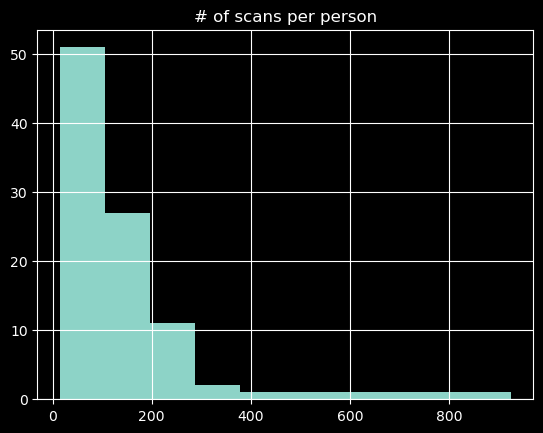

In [9]:
all_samples_df.groupby('person_id').size().hist()
plt.title("# of scans per person")

In [10]:
all_samples_df.to_csv(all_data_path / 'samples.csv')

# Analyze samples.csv

Analyze agreement between differently labeled scans

In [74]:
import torch
import nibabel as nib
import random


In [13]:
df = pd.read_csv(all_data_path / 'samples.csv', index_col = 0)

In [ ]:
dups = df[df[['path', 'scan_num']].duplicated(keep=False)]
dups_df = dups.sort_values(['path', 'scan_num'])
dups_df = dups_df[dups_df['label'].isin([0, 1, 2])] # drop the scans that weren't labeled at all b/c they were at ends of the scan

print(f"There are {len(dups_df)/2} duplicate scans")

There are 849.0 duplicate scans


In [53]:
dups_df['label'].value_counts()

label
0    1181
1     505
2      12
Name: count, dtype: int64

In [55]:
dup_labels = dups_df.groupby(['path', 'scan_num'])['label']

all_equal = dup_labels.nunique().eq(1)
has_2 = dup_labels.apply(lambda x: (x == 2).any())

matches = all_equal | has_2

print(matches.value_counts())
print(f"\nAgreement: {matches.mean():.4f}")

label
True     708
False    141
Name: count, dtype: int64

Agreement: 0.8339


In [69]:
disagree_paths = matches[~matches].index.tolist()
disagree_paths[:5]

[('/data/vision/polina/users/marcusbl/data/anon-00003/stack_8/clean/dicoms.npy',
  8),
 ('/data/vision/polina/users/marcusbl/data/anon-00012-scan-1/stack_2/clean/dicoms.npy',
  3),
 ('/data/vision/polina/users/marcusbl/data/anon-00012-scan-1/stack_2/clean/dicoms.npy',
  7),
 ('/data/vision/polina/users/marcusbl/data/anon-00012-scan-1/stack_2/clean/dicoms.npy',
  8),
 ('/data/vision/polina/users/marcusbl/data/anon-00012-scan-1/stack_2/clean/dicoms.npy',
  17)]

In [ ]:
def read_scan(scan_path: Path, scan_num: int) -> torch.Tensor:
    """
    Returns np array corresponding to the scan for idx in the samples DataFrame 
    """

    if scan_path.suffix == '.npy':
        nifti_data = np.load(scan_path)
    else:
        nifti_img = nib.load(scan_path)
        nifti_data = nifti_img.get_fdata().astype(np.float32)

    return torch.from_numpy(nifti_data)[:, :, scan_num]


/data/vision/polina/users/marcusbl/data/anon-00103-4-4-2014/stack_34/clean/dicoms.npy 25


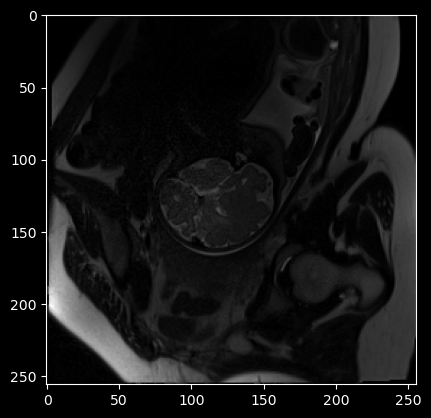

In [102]:
scan_path, scan_num = random.choice(disagree_paths)
print(scan_path, scan_num)
img = read_scan(Path(scan_path), scan_num)
plt.imshow(img, cmap="gray")